# Supplementary Figure S42: LR-prior ablation and stVCR comparison

These cells read the included numerical results, calculate the panel summaries, and draw new figures.

## Run the notebook

This page starts with the paper's saved inputs. Run its Python cells from top to bottom to create the output shown here.

To repeat the model calculations first, use the [analysis and input guide](../../reference/figure_sources/lr-prior-stvcr.md). It identifies the model, data, analysis programs, and the files read by this notebook. Choose that route only if you want to recalculate those inputs.

## Imports and configuration

In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    load_lr_prior_stvcr_results,
    lr_prior_stvcr_statistics,
    plot_lr_prior_stvcr,
    write_lr_prior_stvcr_tables,
)

output_dir = Path("outputs") / "lr_prior_stvcr"
output_dir.mkdir(parents=True, exist_ok=True)

## Load processed results

In [2]:
results = load_lr_prior_stvcr_results()
display(results.no_lr.head())
display(results.stvcr.head())

,dataset,target,space,metric,full,no_lr_prior,no_lr_prior_minus_full,no_lr_prior_relative_to_full
0,zebrafish,1,joint,sliced_w2,0.027367,0.048532,0.021165,0.773384
1,zebrafish,1,spatial,sliced_w2,0.016100,0.019290,0.003190,0.198120
2,zebrafish,1,state,sliced_w2,0.027621,0.053158,0.025537,0.924544
3,zebrafish,2,joint,sliced_w2,0.038902,0.058765,0.019863,0.510584
4,zebrafish,2,spatial,sliced_w2,0.019253,0.026927,0.007674,0.398610


,dataset,target,space,CytoBridge-0.015,stVCR,stvcr_minus_cytobridge,stvcr_relative_to_cytobridge
0,zebrafish,1,joint,0.058313,0.110448,0.052135,0.894050
1,zebrafish,1,spatial,0.049454,0.189775,0.140321,2.837419
2,zebrafish,1,state,0.056534,0.106451,0.049917,0.882957
3,zebrafish,2,joint,0.056431,0.124771,0.068340,1.211034
4,zebrafish,2,spatial,0.044071,0.299843,0.255772,5.803604


## Recalculate panel data

Full and No-LR are independently trained matched models from one seed. The CytoBridge–stVCR comparison uses separate LOTO fits and predictions produced directly by stVCR. Each target–space value averages five projection sets before pairing; s.e.m. is calculated across target stages.

In [3]:
display(results.panel_summary)

,comparison,dataset,space,n_targets,mean_relative_difference,sem,dataset_mean_relative_difference
0,No LR prior minus full model,zebrafish,joint,4,0.079843,0.369134,0.135283
1,No LR prior minus full model,zebrafish,spatial,4,0.189165,0.157592,0.135283
2,No LR prior minus full model,zebrafish,state,4,0.136841,0.409225,0.135283
3,No LR prior minus full model,mosta,joint,3,0.317666,0.276717,0.261302
4,No LR prior minus full model,mosta,spatial,3,0.019503,0.131026,0.261302
5,No LR prior minus full model,mosta,state,3,0.446737,0.398854,0.261302
6,No LR prior minus full model,arista,joint,4,1.958326,0.317498,1.772661
7,No LR prior minus full model,arista,spatial,4,0.143338,0.047017,1.772661
8,No LR prior minus full model,arista,state,4,3.216319,0.775124,1.772661
9,No LR prior minus full model,admouse,joint,2,0.238860,0.092172,0.254568


## Render and save the figure

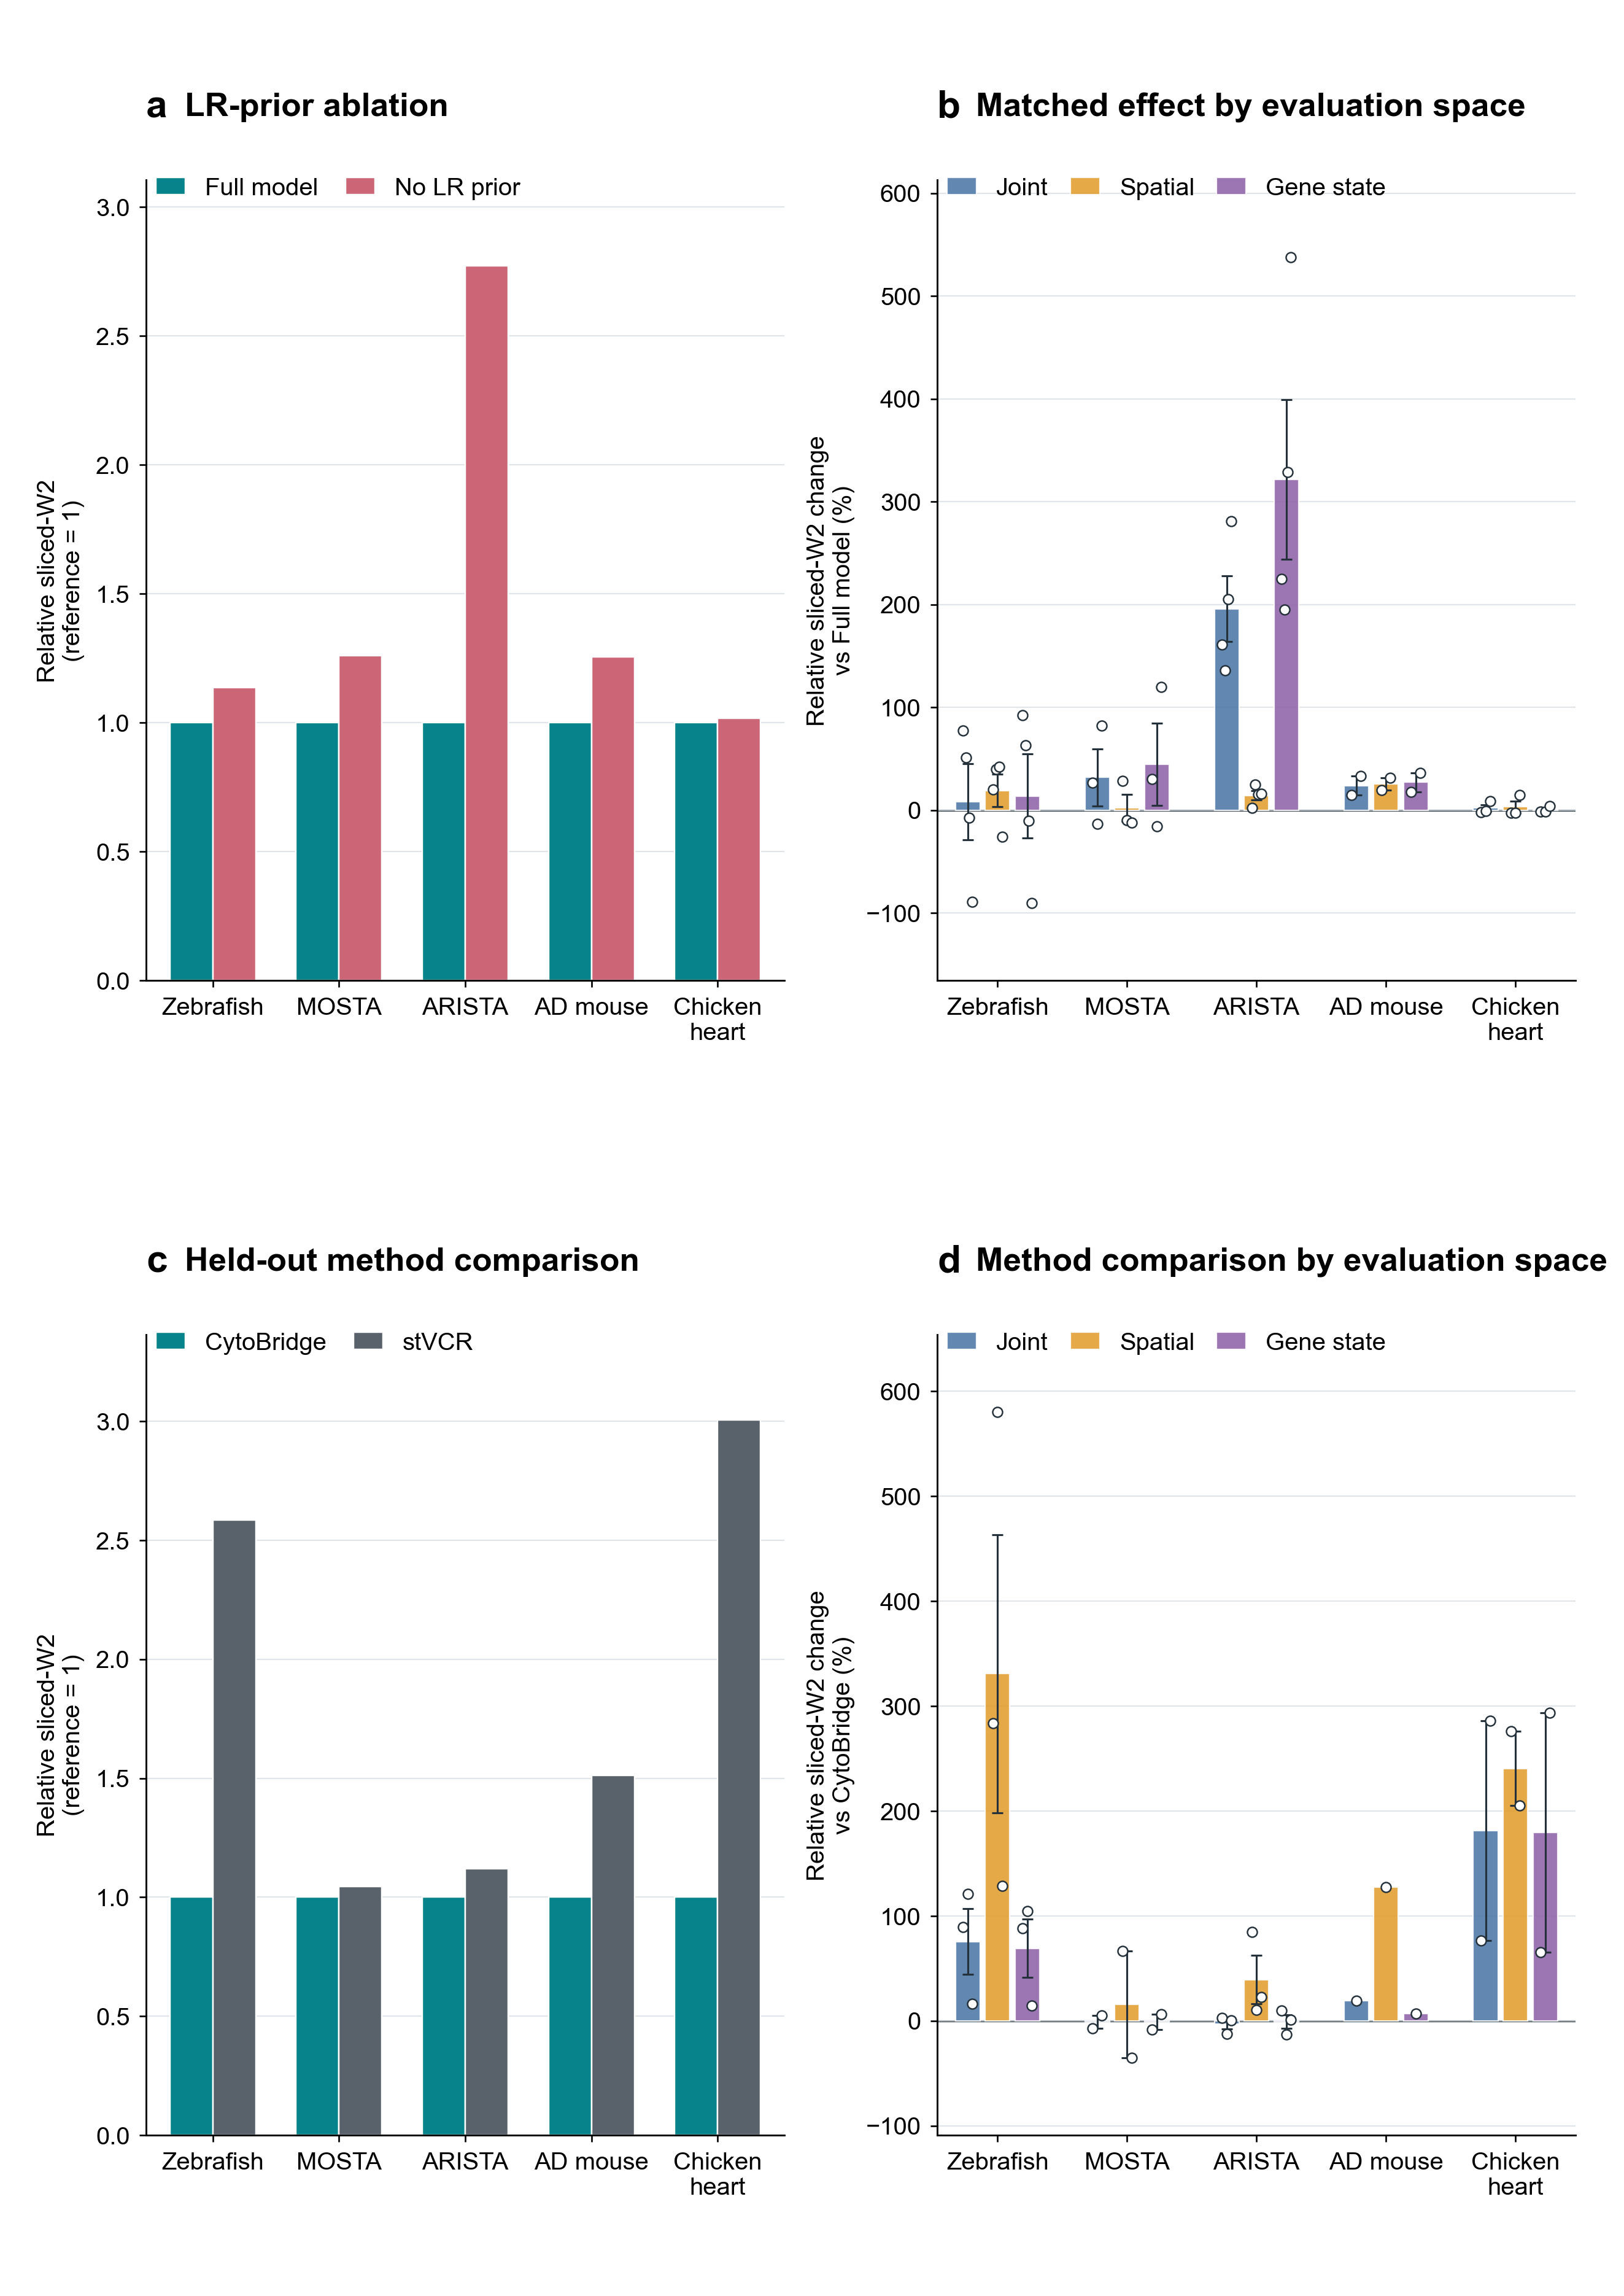

In [4]:
table_paths = write_lr_prior_stvcr_tables(results, output_dir)
pdf_path, png_path = plot_lr_prior_stvcr(results, output_dir)
display(Image(filename=str(png_path), width=700))

## Check outputs

In [5]:
{
    "statistics": lr_prior_stvcr_statistics(results),
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}

{'statistics': {'matched_cells': 48,
  'external_comparison_cells': 33,
  'panel_summary_rows': 30,
  'no_lr_mean_relative_change_arista': 1.772661196476827,
  'no_lr_mean_relative_change_chicken_heart': 0.01817799522095409},
 'tables': {'no_lr': True, 'external_comparison': True, 'panel_summary': True},
 'pdf': True,
 'png': True}

## Use results from another run

Pass another directory of paired No-LR and stVCR result tables to the installed command:

```bash
cytobridge figure lr-prior-stvcr --results-dir <paired-results> --output-dir outputs/lr_prior_stvcr
```